# LightGBM 이커머스 이탈 예측 모델링

- Baseline부터 최종 모델 확정까지 전체 과정
- `data/preprocessed/`의 전처리된 데이터를 사용하며, **test 데이터는 맨 마지막
최종 평가 전까지 이 노트북에서 전혀 사용하지 않음.**

**평가 기준(팀 합의)**: Recall 우선 (이탈 고객을 놓치지 않는 것이 중요), Precision·AUC 함께 기록.
단, 탐색 단계(Optuna)의 최적화 목표는 AUC를 사용 — Recall만 직접 최적화하면 "전부 이탈로
예측"하는 식의 퇴화해 버릴 수 있어(Recall=1이지만 무의미), threshold에 안정적인 AUC로 좋은 모델을
찾고, 최종 후보 비교/보고는 Recall 중심으로 함.

## 0. 데이터 로드

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 노트북 실행 위치에 관계없이 프로젝트 루트의 data 폴더를 찾음
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "preprocessed").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("data/preprocessed 폴더를 찾을 수 없음")
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "preprocessed"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_val   = pd.read_csv(DATA_DIR / "X_val.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]
y_val   = pd.read_csv(DATA_DIR / "y_val.csv")["churn"]

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))

## 1단계: Baseline 모델
하이퍼파라미터 튜닝 없이 LightGBM 기본값 그대로 학습해 기준 성능잡기

In [18]:
baseline_model = LGBMClassifier(random_state=42, verbose=-1)
baseline_model.fit(X_train, y_train)

def evaluate(model, X, y, dataset_name):
    """recall을 맨 앞에 두어 팀 평가 기준(Recall 우선)에 맞춤"""
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        "dataset": dataset_name,
        "recall": recall_score(y, pred),
        "precision": precision_score(y, pred),
        "auc": roc_auc_score(y, proba),
        "accuracy": accuracy_score(y, pred),
        "f1": f1_score(y, pred),
    }

baseline_results = pd.DataFrame([
    evaluate(baseline_model, X_train, y_train, "train"),
    evaluate(baseline_model, X_val, y_val, "val"),
])
print(baseline_results.set_index("dataset").T.round(3))

dataset    train    val
recall     0.928  0.665
precision  0.910  0.671
auc        0.978  0.741
accuracy   0.919  0.674
f1         0.919  0.668


### 해석
- train recall 0.928 vs val recall 0.665, train AUC 0.978 vs val AUC 0.741 → train-val 격차가 커서
  뚜렷한 과적합
- val recall 0.665는 이탈 고객 3명 중 1명을 놓치는 수준 → 다음 단계에서 과적합을 줄이며
  recall도 같이 개선을 노려봄

## 2단계: 정규화 + Early Stopping
트리 복잡도를 제한하고 규제항을 추가해 과적합을 완화합니다.

In [19]:
tuned_model = LGBMClassifier(
    n_estimators=100,        # 많이 잡아두고 early stopping이 알아서 멈추게 함
    learning_rate=0.03,       # baseline(0.1)보다 조심스럽게 학습
    num_leaves=15,            # baseline(31)보다 트리를 단순하게
    max_depth=5,              # 트리 깊이 제한
    min_child_samples=30,     # 리프 노드 최소 샘플 수 (노이즈 방지)
    reg_alpha=0.1,            # L1 규제
    reg_lambda=0.1,           # L2 규제
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
tuned_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)],
);

tuned_results = pd.DataFrame([
    evaluate(tuned_model, X_train, y_train, "train"),
    evaluate(tuned_model, X_val, y_val, "val"),
])
print(tuned_results.set_index("dataset").T.round(3))

dataset    train    val
recall     0.802  0.740
precision  0.726  0.695
auc        0.838  0.769
accuracy   0.753  0.711
f1         0.762  0.717


### 해석
- train-val AUC 격차 0.237 → 0.069로 크게 완화, val AUC는 0.741 → 0.769로 개선
  (부트스트랩 95% 신뢰구간 [0.013, 0.043]으로 통계적으로 유의미)
- val recall도 0.665 → 0.740으로 함께 개선됨
- 다만 규제 강도를 손으로 정한 값이라 최적은 아님 → 다음 단계에서 체계적으로 탐색

## 3단계: Optuna 하이퍼파라미터 탐색
넓은 범위를 자동으로 탐색해 val AUC를 최대화하는 조합을 찾음(탐색 목표는 AUC, 최종 판단은 이후 단계에서 Recall로).

In [20]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "verbose": -1,
    }
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric="auc",
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)])
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

# 확정 모델 재학습 (10개 피처 기준 최종 후보)
best_params_10f = {**study.best_params, "n_estimators": 1000, "random_state": 42, "verbose": -1}
best_model_10f = LGBMClassifier(**best_params_10f)
best_model_10f.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(50, verbose=False),   # verbose=False로 로그 숨김
        lgb.log_evaluation(period=0),
    ],
);

# ── 결과를 표 형태로 깔끔하게 출력 ──────────────────────────
print(f"최고 val AUC: {study.best_value:.4f}  (트리 {best_model_10f.best_iteration_}개 사용)\n")
print("최적 하이퍼파라미터")
print(pd.Series(study.best_params, name="value").round(4).to_string())

  0%|          | 0/100 [00:00<?, ?it/s]

최고 val AUC: 0.7757  (트리 7개 사용)

최적 하이퍼파라미터
learning_rate         0.0591
num_leaves           34.0000
max_depth             4.0000
min_child_samples    20.0000
reg_alpha             0.0130
reg_lambda            0.5494
subsample             0.9350
colsample_bytree      0.8158


### 해석
- val AUC 0.7757 (2단계 대비 +0.007) → 하이퍼파라미터 튜닝만으로는 개선 여지가 거의 소진됨
- 이 시점의 판단 기준은 AUC(탐색 목표)이며, Recall 기준 최종 비교는 피처 엔지니어링 이후
  5-1단계에서 진행
- 다음은 피처 자체를 늘려보는 방향으로 전환

## 4단계: Feature Importance / SHAP 해석
지금 모델이 어떤 피처를 근거로 판단하는지 확인해 다음 피처 엔지니어링 방향잡기

                feature  importance
            net_revenue          31
avg_days_between_orders          22
           recency_days          19
      distinct_products          11
              frequency           9
            tenure_days           5
  recent_activity_ratio           2
           is_low_value           0
                  is_uk           0
             has_return           0


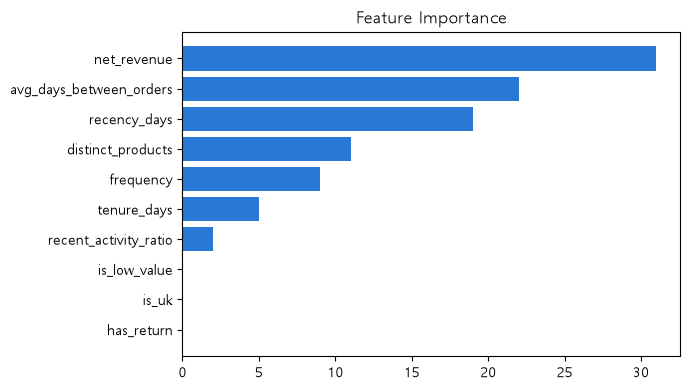

C:\Users\User\miniforge3\envs\pystudy_env\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


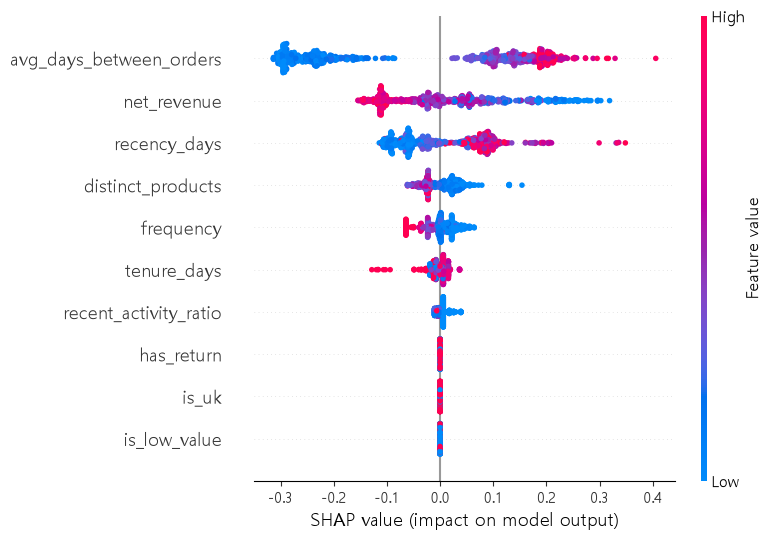

In [21]:
import shap
import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model_10f.feature_importances_,
}).sort_values("importance", ascending=False)
print(importance_df.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#2a78d6")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(best_model_10f)
shap_values = explainer.shap_values(X_val)
if isinstance(shap_values, list):
    # LightGBM 이진분류 + 최신 shap 버전에서 [클래스0 배열, 클래스1 배열] 리스트로 반환됨
    shap_values = shap_values[1]  # 양성 클래스(이탈=1) 기준만 사용

shap.summary_plot(shap_values, X_val)

### 해석
- 상위 4개(`net_revenue`, `avg_days_between_orders`, `recency_days`, `distinct_products`)가 예측력 대부분을 차지
- `is_low_value`, `is_uk`, `has_return`은 importance/SHAP 모두 0
  - `is_uk`: 원본 EDA에서도 47%→50%로 약한 신호였음 → 실제로 무의미할 가능성이 높음
  - `is_low_value`: 기반이 된 `avg_order_value`가 원래 상관 -0.04로 무신호였고, 개념이 겹치는
    `net_revenue`가 이미 강하게 들어가 있어 정보가 중복됐을 가능성
  - `has_return`: 원본 EDA에서는 59%→37%로 격차가 꽤 컸음 → tree 개수가 적어서(best_iteration=7)
    아직 못 쓴 것일 가능성이 있어 6단계 K-fold에서 재확인 필요
- 상위 피처를 더 세분화한 새 피처를 추가해보기로 결정

## 5단계: 피처 엔지니어링
`preprocessor.pkl`로 스케일링을 원복해 원래 단위로 되돌린 뒤, 상위 피처를 조합한 새 피처 3개를 추가합니다.

In [22]:
import joblib
from sklearn.preprocessing import StandardScaler

preprocessor = joblib.load(DATA_DIR / "preprocessor.pkl")

def inverse_scale(df, ct):
    """
    ColumnTransformer 내부 단계를 거꾸로 적용해 원래 단위로 복원.
    원본 파일(X_train.csv 등)과 preprocessor.pkl은 읽기만 하고 수정하지 않음 -
    복사본(df.copy())에서만 작업하고, 이후 다시 스케일링해서 원상태로 되돌림.
    """
    df = df.copy()
    for name, transformer, cols in ct.transformers_:
        if isinstance(transformer, str):
            continue
        cols = list(cols)
        if hasattr(transformer, "steps"):  # Pipeline (예: net_revenue의 clip->log->scale)
            values = df[cols].values
            for step_name, step in reversed(transformer.steps):
                if step_name == "scale":
                    values = step.inverse_transform(values)
                elif step_name == "log":
                    values = np.expm1(values)  # log1p의 역연산
            df[cols] = values
        else:
            df[cols] = transformer.inverse_transform(df[cols])
    return df

X_train_orig = inverse_scale(X_train, preprocessor)
X_val_orig   = inverse_scale(X_val, preprocessor)

def add_features(df):
    df = df.copy()
    # 자기 구매 리듬 대비 얼마나 늦었나 (분모 0 방지로 +1)
    df["recency_ratio"] = df["recency_days"] / (df["avg_days_between_orders"] + 1)
    # 주문 1건당 상품 다양성
    df["product_diversity_ratio"] = df["distinct_products"] / df["frequency"]
    # 가입기간 대비 하루 평균 지출 (분모 0 방지로 +1)
    df["revenue_per_day"] = df["net_revenue"] / (df["tenure_days"] + 1)
    return df

X_train_fe = add_features(X_train_orig)
X_val_fe   = add_features(X_val_orig)

continuous_cols = ["recency_days", "frequency", "distinct_products", "net_revenue",
                    "tenure_days", "avg_days_between_orders"]
new_cols = ["recency_ratio", "product_diversity_ratio", "revenue_per_day"]
all_continuous = continuous_cols + new_cols

new_scaler = StandardScaler()
X_train_fe[all_continuous] = new_scaler.fit_transform(X_train_fe[all_continuous])
X_val_fe[all_continuous]   = new_scaler.transform(X_val_fe[all_continuous])

print(f"피처 {X_train.shape[1]}개 -> {X_train_fe.shape[1]}개\n")
print("새로 추가된 피처 (원래 단위 기준, 스케일링 전)")
print(X_train_orig.pipe(add_features)[new_cols].describe().round(2))

피처 10개 -> 13개

새로 추가된 피처 (원래 단위 기준, 스케일링 전)
       recency_ratio  product_diversity_ratio  revenue_per_day
count        2592.00                  2592.00          2592.00
mean            1.40                    16.00             7.38
std             1.54                    15.46            23.53
min             0.00                     0.17             0.00
25%             0.69                     6.50             1.41
50%             1.00                    12.00             2.90
75%             1.79                    20.33             6.50
max            41.83                   164.00           651.92


## 5-1단계: 새 피처셋(13개)으로 재튜닝
피처 구성이 바뀌면 최적 하이퍼파라미터도 달라지므로 재탐색

In [23]:
def objective_fe(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "verbose": -1,
    }
    model = LGBMClassifier(**params)
    model.fit(X_train_fe, y_train, eval_set=[(X_val_fe, y_val)], eval_metric="auc",
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)])
    return roc_auc_score(y_val, model.predict_proba(X_val_fe)[:, 1])

study_fe = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_fe.optimize(objective_fe, n_trials=100, show_progress_bar=True)

# 13개 피처 기준 최종 모델 재학습
best_params_13f = {**study_fe.best_params, "n_estimators": 1000, "random_state": 42, "verbose": -1}
model_fe = LGBMClassifier(**best_params_13f)
model_fe.fit(
    X_train_fe, y_train,
    eval_set=[(X_val_fe, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)],
);

# ── 팀 평가 기준(Recall 우선)으로 두 후보(10개 vs 13개) 비교 ──────
def eval_recall_first(model, X, y, name):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        "model": name,
        "recall": recall_score(y, pred),
        "precision": precision_score(y, pred),
        "auc": roc_auc_score(y, proba),
    }

comparison = pd.DataFrame([
    eval_recall_first(best_model_10f, X_val, y_val, "10개 피처(3단계)"),
    eval_recall_first(model_fe, X_val_fe, y_val, "13개 피처(5-1단계)"),
])
print(comparison.set_index("model").round(4))

  0%|          | 0/100 [00:00<?, ?it/s]

               recall  precision     auc
model                                   
10개 피처(3단계)    0.7518     0.6918  0.7757
13개 피처(5-1단계)  0.7330     0.6894  0.7770


### 해석 및 판단

| model | recall | precision | auc |
|---|---|---|---|
| 10개 피처(3단계) | 0.7518 | 0.6918 | 0.7757 |
| 13개 피처(5-1단계) | 0.7330 | 0.6894 | 0.7770 |

- AUC는 13개 피처가 근소하게 높지만(+0.0013, 노이즈 수준) **팀의 우선 지표인 Recall은
  10개 피처가 1.9%p 더 높음** (0.7518 vs 0.7330)
- 새로 추가한 3개 피처(`recency_ratio`, `product_diversity_ratio`, `revenue_per_day`)는
  전부 기존 피처의 비율/재조합이라 새로운 정보가 거의 없었고, Recall 기준으로는 오히려 소폭 손해
- **Recall 우선 기준으로도, 단순성(Occam's razor) 기준으로도 10개 피처 모델이 우세
  → 10개 피처를 최종 채택**

## 6단계: K-fold 교차검증
최종 후보(10개 피처 + 3단계 하이퍼파라미터)가 특정 val 분할에 우연히 잘 맞은 건 아닌지,
train+val을 5등분해 recall/precision/auc를 함께 재확인

In [24]:
from sklearn.model_selection import StratifiedKFold, train_test_split

X_pool = pd.concat([X_train, X_val], ignore_index=True)
y_pool = pd.concat([y_train, y_val], ignore_index=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (tr_idx, ho_idx) in enumerate(skf.split(X_pool, y_pool), 1):
    X_fold_train, X_fold_holdout = X_pool.iloc[tr_idx], X_pool.iloc[ho_idx]
    y_fold_train, y_fold_holdout = y_pool.iloc[tr_idx], y_pool.iloc[ho_idx]

    # early stopping용으로 fold의 학습 파트를 다시 80/20으로 쪼갬
    # (10%는 조각이 너무 작아 early stopping이 불안정했음 -> 20%로 확대해 안정화)
    X_tr, X_es, y_tr, y_es = train_test_split(
        X_fold_train, y_fold_train, test_size=0.2, stratify=y_fold_train, random_state=42
    )

    model = LGBMClassifier(n_estimators=1000, **study.best_params, random_state=42, verbose=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], eval_metric="auc",
              callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(period=0)])

    pred = model.predict(X_fold_holdout)
    proba = model.predict_proba(X_fold_holdout)[:, 1]
    result = {
        "fold": fold,
        "recall": recall_score(y_fold_holdout, pred),
        "precision": precision_score(y_fold_holdout, pred),
        "auc": roc_auc_score(y_fold_holdout, proba),
        "n_trees": model.best_iteration_,
    }
    fold_results.append(result)
    print(f"Fold {fold}: recall={result['recall']:.4f}  precision={result['precision']:.4f}  "
          f"auc={result['auc']:.4f}  (트리 {result['n_trees']}개)")

fold_df = pd.DataFrame(fold_results).set_index("fold")
print("\n5-fold 평균 ± 표준편차")
print(fold_df[["recall", "precision", "auc"]].agg(["mean", "std"]).round(4))

Fold 1: recall=0.7398  precision=0.6970  auc=0.7834  (트리 13개)
Fold 2: recall=0.7222  precision=0.6712  auc=0.7710  (트리 47개)
Fold 3: recall=0.7331  precision=0.6831  auc=0.7658  (트리 123개)
Fold 4: recall=0.7419  precision=0.6894  auc=0.7810  (트리 154개)
Fold 5: recall=0.7801  precision=0.6768  auc=0.7720  (트리 45개)

5-fold 평균 ± 표준편차
      recall  precision     auc
mean  0.7434     0.6835  0.7746
std   0.0219     0.0101  0.0074


### 해석
- 5-fold 결과: recall 평균 0.7434(±0.022), precision 평균 0.6835(±0.010), auc 평균 0.7746(±0.007)
  → 세 지표 모두 fold별 편차가 작아 안정적임
- 단일 val 결과(recall 0.7518, precision 0.6918, auc 0.7757)와 5-fold 평균이 표준편차 범위 안에서
  잘 일치함 → **특정 데이터 분할에 우연히 잘 맞았던 것이 아니라, 모델이 안정적으로 이 정도
  성능을 낸다고 볼 수 있음**
- (참고) 처음엔 early stopping 내부 검증 조각이 너무 작아(10%) fold 2에서 트리 1개로 조기
  종료되며 recall이 0.56까지 튀는 불안정한 결과가 나왔음. 검증 조각을 20%로 늘리고
  patience를 100으로 늘려 재확인한 결과가 위 수치임

## 최종 정리

**평가 기준**: Recall 우선(이탈 고객을 놓치지 않는 것이 중요), Precision·AUC 함께 기록

**시도한 것들**

1. Baseline (기본 하이퍼파라미터) → val recall 0.665 / auc 0.741, 과적합 뚜렷 (train-val AUC 격차 0.237)
2. 수동 정규화 + Early Stopping → val recall 0.740 / auc 0.769, 격차 0.069로 완화
3. Optuna 하이퍼파라미터 탐색(100회, AUC 기준) → val auc 0.776
4. Feature Importance / SHAP 확인 → 상위 4개 피처가 예측력 대부분 차지, 3개 피처는 기여도 0
5. 피처 엔지니어링(3개 추가, 13개로 확장) + 재튜닝 → val recall 0.733 / auc 0.777
6. K-fold 교차검증(5-fold) → recall 0.743(±0.022), precision 0.684(±0.010), auc 0.775(±0.007)로 단일 val 결과와 유사, 특정 분할 의존 없음을 확인

**결론**

팀 평가 기준(Recall 우선, Precision·AUC 함께 기록)에 따라 10개 피처와 13개 피처 모델을
비교했다. AUC는 두 모델이 거의 동일했으나(13개가 +0.0013 근소 우위, 노이즈 수준),
**Recall은 10개 피처 모델이 0.7518로 13개 피처(0.7330)보다 1.9%p 높아 명확히 우세했다.**
추가한 3개 피처가 기존 피처의 재조합에 그쳐 새로운 정보를 제공하지 못한 것으로 판단되며,
Recall 우선 기준과 단순성(Occam's razor) 양쪽 모두에서 **10개 피처 모델(3단계 하이퍼파라미터)을
최종 모델로 채택**한다. 5-fold 교차검증으로 특정 데이터 분할에 대한 과도한 의존이 없음을 확인했다.

**다음 단계**: 이 노트북에서 확정된 모델(10개 피처 + 3단계 하이퍼파라미터)로 test 데이터
최종 평가만 남았다 (별도 노트북에서 1회만 진행 예정).